In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, auc,r2_score, roc_auc_score,roc_curve,confusion_matrix,average_precision_score
import numpy as np
import sweetviz as sv
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


In [2]:
directorio = "Analizadas"
rangos = [str(x) for x in range(32, 42) if x != 37 and x != 34]
dataframes = []

for numero in rangos:
    nombre_archivo = f'B2400{numero} Genotypes Table.txt'
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    df = pd.read_csv(ruta_archivo, delimiter='\t', skiprows=range(1, 22))
    dataframes.append(df)

Analizadas = pd.concat(dataframes, ignore_index=True)

directorio = "Sin_Analizar"
dataframes = []
for numero in rangos:
    nombre_archivo = f'B2400{numero} sin analizar Genotypes Table.txt'
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    df = pd.read_csv(ruta_archivo, delimiter='\t', skiprows=range(1, 22))
    dataframes.append(df)

NOAnalizadas = pd.concat(dataframes, ignore_index=True)


In [3]:
NOAnalizadas['Allele 1'] = NOAnalizadas['Allele 1'].replace({'X': 0, 'Y': 1,"?":np.nan})
NOAnalizadas['Allele 2'] = NOAnalizadas['Allele 2'].replace({'X': 0, 'Y': 1,"?":np.nan})
Analizadas['Allele 1'] = Analizadas['Allele 1'].replace({'X': 0, 'Y': 1})
Analizadas['Allele 2'] = Analizadas['Allele 2'].replace({'X': 0, 'Y': 1})

columnas_a_convertir = ['Allele 1', 'Allele 2']
Analizadas[columnas_a_convertir] = Analizadas[columnas_a_convertir].astype('float64')
NOAnalizadas[columnas_a_convertir] = NOAnalizadas[columnas_a_convertir].astype('float64')
NOAnalizadas['CorregirA2'] = np.where(
    NOAnalizadas['Allele 2'].isna() & ~Analizadas['Allele 2'].isna(),  # Una es NaN y la otra no (NaN → Entero)
    2,
    np.where(
        ~NOAnalizadas['Allele 2'].isna() & ~Analizadas['Allele 2'].isna() & (NOAnalizadas['Allele 2'] != Analizadas['Allele 2']),  # Ambas no NaN pero diferentes (Entero → Entero diferente)
        1,
        np.where(
            ~NOAnalizadas['Allele 2'].isna() & Analizadas['Allele 2'].isna(),  # Entero → NaN
            3,
            0  # Ambas NaN o iguales
        )
    )
)


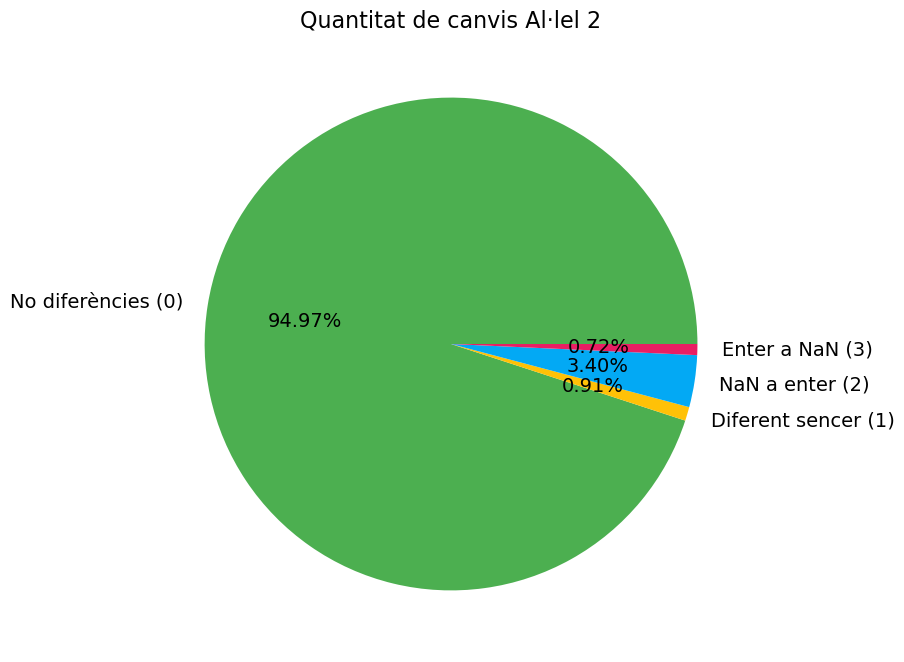

In [4]:
comparison_counts = NOAnalizadas['CorregirA2'].value_counts().sort_index()

labels = ['No diferències (0)', 'Diferent sencer (1)', 'NaN a enter (2)', 'Enter a NaN (3)']
colors = ['#4CAF50', '#FFC107', '#03A9F4', '#E91E63']

plt.figure(figsize=(8, 8))
plt.pie(
    comparison_counts, 
    labels=labels, 
    autopct='%1.2f%%', 
    colors=colors,
    textprops={'fontsize': 14}  # Aumenta el tamaño de letra de etiquetas y porcentajes
)
plt.title('Quantitat de canvis Al·lel 2', fontsize=16)  # Aumenta el tamaño del título
plt.show()

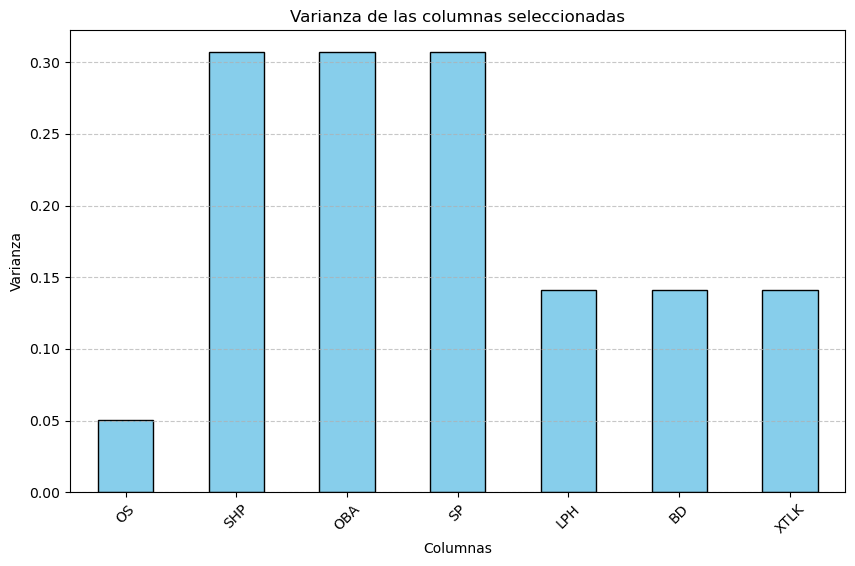

In [5]:
# Seleccionar las columnas de interés (ajusta los nombres)
columnas_interes = ["OS", "SHP", "OBA","SP","LPH","BD","XTLK"]  # Sustituye por los nombres reales
X_subset = NOAnalizadas[columnas_interes]

# Calcular la varianza de cada columna seleccionada
varianzas = X_subset.var()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
varianzas.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("Columnas")
plt.ylabel("Varianza")
plt.title("Varianza de las columnas seleccionadas")
plt.xticks(rotation=45)  # Rotar etiquetas para mejor visualización
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [6]:
Analizadas.describe()

,Allele 1,Allele 2,Allele 3,Size 1,Size 2,Size 3,Height 1,Height 2,Height 3,Peak Area 1,...,PHR,LPH,SPU,AN,BD,XTLK,GQ,CV,UD1,Unnamed: 37
count,15590.000000,10657.000000,8.00000,15590.000000,10657.000000,8.000000,15590.000000,10657.000000,8.00000,15590.000000,...,15960.000000,15960.000000,15960.00000,15960.000000,15960.000000,15960.000000,15960.000000,0.0,0.0,0.0
mean,170.703015,176.755278,103.00000,177.597182,182.005890,98.045000,7118.707184,4348.728160,2508.25000,50307.637203,...,-0.809273,-0.337093,-0.33515,-0.259962,-0.337093,-0.336905,0.767208,NaN,NaN,NaN
std,70.450686,67.780923,1.85164,59.478545,58.827249,1.939735,4598.362195,2435.834168,1079.48053,32471.484648,...,1.136287,1.047839,1.04400,1.016328,1.047839,1.047451,0.273562,NaN,NaN,NaN
min,0.000000,0.000000,101.00000,79.180000,84.350000,95.720000,138.000000,89.000000,888.00000,959.000000,...,-4.000000,-4.000000,-4.00000,-4.000000,-4.000000,-4.000000,0.000000,NaN,NaN,NaN
25%,120.000000,126.000000,101.00000,123.680000,127.540000,96.155000,3843.000000,2584.000000,1914.50000,27104.500000,...,-2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.487000,NaN,NaN,NaN
50%,162.000000,168.000000,103.00000,178.755000,200.490000,97.905000,6118.000000,3971.000000,2601.00000,43346.500000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.974000,NaN,NaN,NaN
75%,231.000000,235.000000,105.00000,229.440000,234.040000,100.027500,9212.000000,5663.000000,3169.25000,65532.750000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.974000,NaN,NaN,NaN
max,296.000000,296.000000,105.00000,295.460000,295.560000,100.320000,32666.000000,25414.000000,4095.00000,302132.000000,...,1.000000,0.000000,1.00000,1.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN


In [5]:
Analizadas = Analizadas.select_dtypes(exclude=['object', 'bool'])
NOAnalizadas = NOAnalizadas.select_dtypes(exclude=['object', 'bool'])

Analizadas = Analizadas.drop(columns=["CV", "Unnamed: 37",
                                      "Allele 3", "Size 3", "Height 3","Peak Area 3",'Data Point 3','UD1'])
NOAnalizadas = NOAnalizadas.drop(columns=[
                                          "CV", "Unnamed: 37", "Size 3", "Height 3","Peak Area 3",'Data Point 3','UD1'])


# Detector

In [51]:
rows_with_0 = NOAnalizadas[NOAnalizadas['CorregirA2'] == 0]
rows_with_1 = NOAnalizadas[NOAnalizadas['CorregirA2']==1]
final_selection = pd.concat([rows_with_0, rows_with_1])

In [55]:
X=final_selection.fillna(-9999)
y=X["CorregirA2"]
X=X.iloc[:,:23]

## Random

In [53]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import SelectFromModel
# Crear el objeto para submuestreo
rus = RandomUnderSampler(random_state=0)

# Aplicar el submuestreo a los datos
X_res, y_res = rus.fit_resample(X, y)

# Ver la distribución de clases después del submuestreo
from collections import Counter
print(Counter(y_res))


Counter({0: 145, 1: 145})


C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


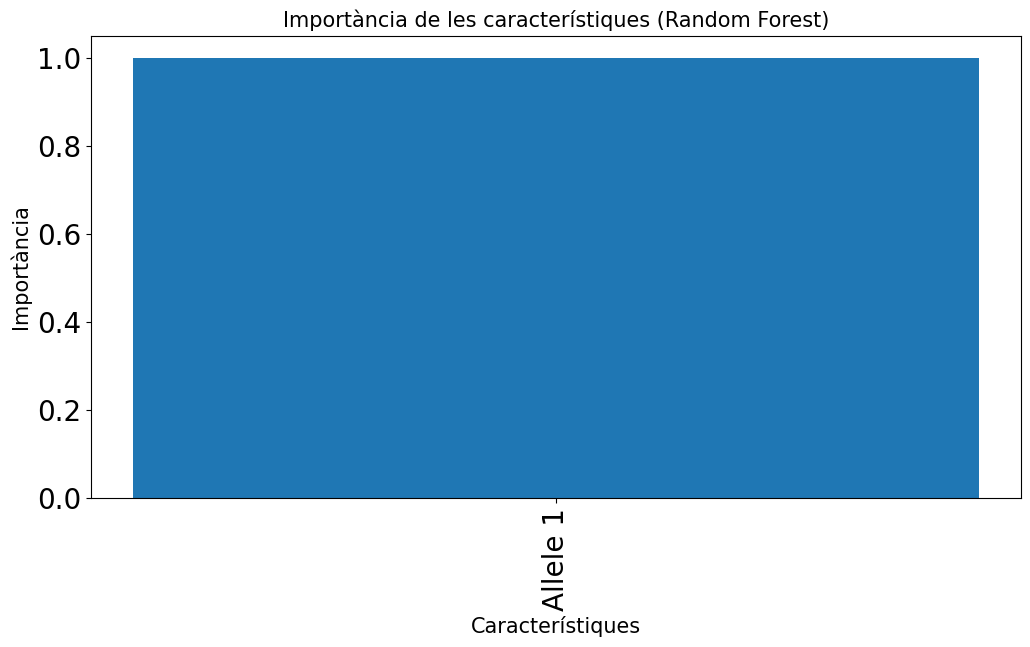

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)


# Obtener los nombres de las características seleccionadas
mask = selector.get_support()
best_feature_names = X_res.columns[mask]

# Obtener la importancia de las características
importances = model.feature_importances_
sorted_indices = np.argsort(importances)[::-1]  # Ordenar por importancia descendente

# Visualizar la importancia de las características
plt.figure(figsize=(12, 6))
plt.title("Importància de les característiques (Random Forest)", fontsize=15)
plt.bar(range(len(importances)), importances[sorted_indices], align="center")
plt.xticks(range(len(importances)), X_res.columns[sorted_indices], rotation=90, fontsize=15)
plt.xlabel("Característiques", fontsize=15)
plt.ylabel("Importància", fontsize=15)
plt.tick_params(axis="both", labelsize=20)
plt.show()




In [ ]:
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
clf.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))


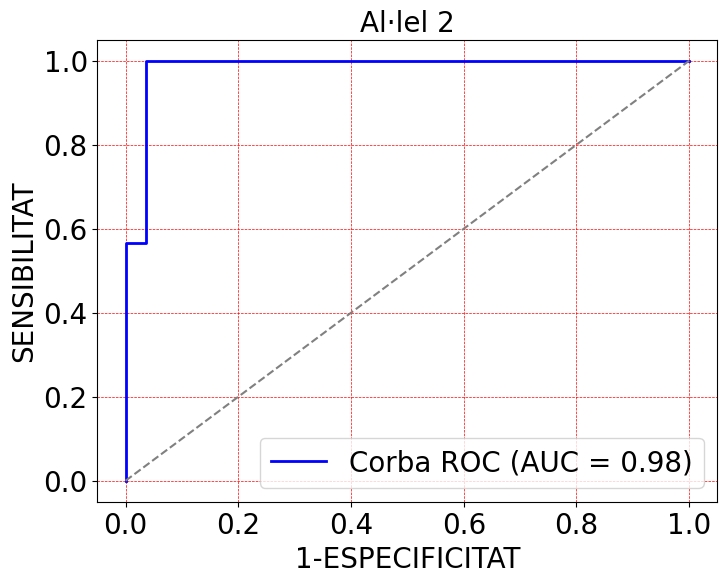

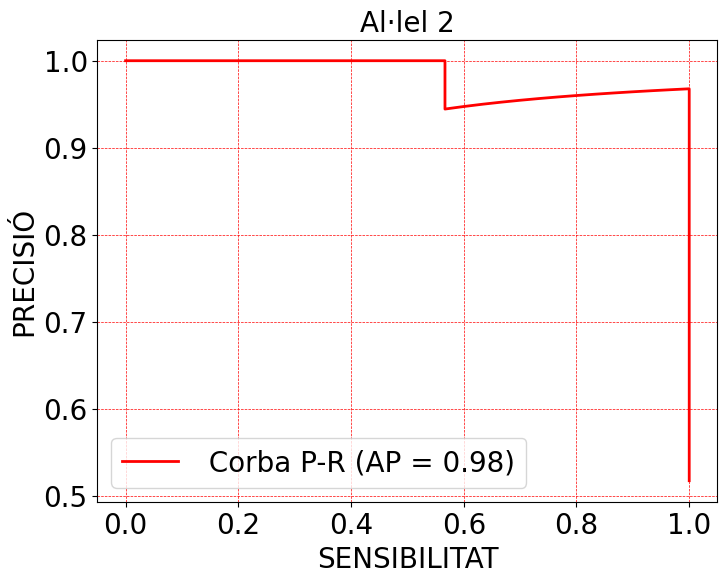

In [13]:
y_proba = clf.predict_proba(X_test)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 2',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Al·lel 2',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()


## TomekLinks

In [14]:
from imblearn.under_sampling import TomekLinks
# Crear el objeto TomekLinks
tomek = TomekLinks()

# Aplicar TomekLinks para submuestreo
X_res, y_res = tomek.fit_resample(X, y)

# Comprobar la distribución de clases
from collections import Counter
print(Counter(y_res))


Counter({0: 15105, 1: 145})


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

clfbo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced_subsample"
    
)
clfbo.fit(X_train_new, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clfbo.predict(X_test_new)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))



C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[[3021    6]
 [   5   18]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3027
           1       0.75      0.78      0.77        23

    accuracy                           1.00      3050
   macro avg       0.87      0.89      0.88      3050
weighted avg       1.00      1.00      1.00      3050



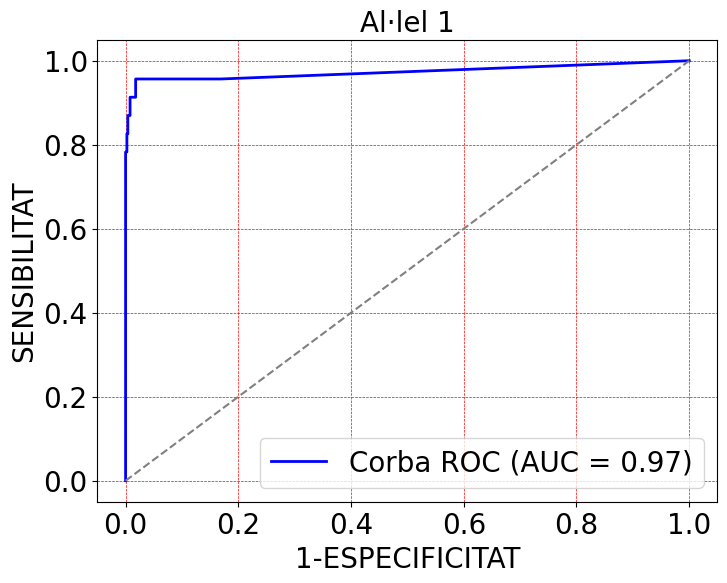

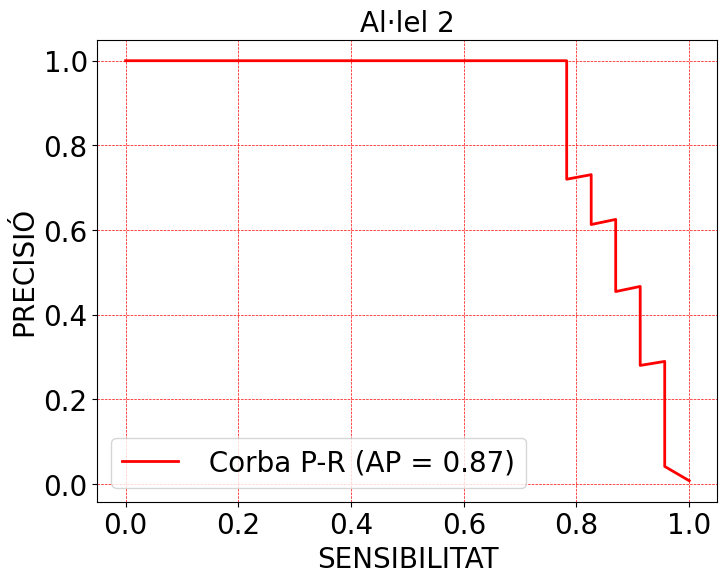

In [17]:
y_proba = clfbo.predict_proba(X_test_new)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Al·lel 2',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

## ClusterCentroids

In [18]:
from imblearn.under_sampling import ClusterCentroids
from collections import Counter

# Crear el objeto ClusterCentroids
cluster = ClusterCentroids(random_state=42)

# Aplicar ClusterCentroids
X_res, y_res = cluster.fit_resample(X, y)

# Comprobar la distribución de clases
print(Counter(y_res))

C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Counter({0: 145, 1: 145})


In [19]:
from sklearn.feature_selection import SelectFromModel
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced_subsample"
    
)
clf.fit(X_train_new, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test_new)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))



C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[[26  2]
 [ 0 30]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        28
           1       0.94      1.00      0.97        30

    accuracy                           0.97        58
   macro avg       0.97      0.96      0.97        58
weighted avg       0.97      0.97      0.97        58



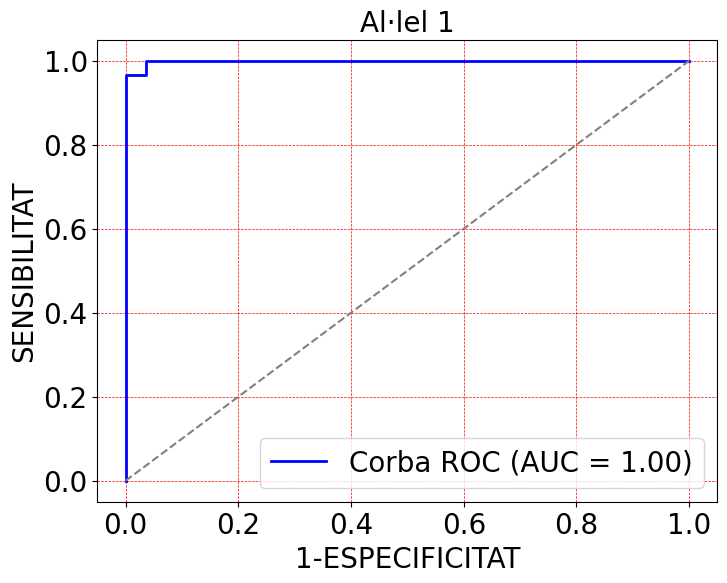

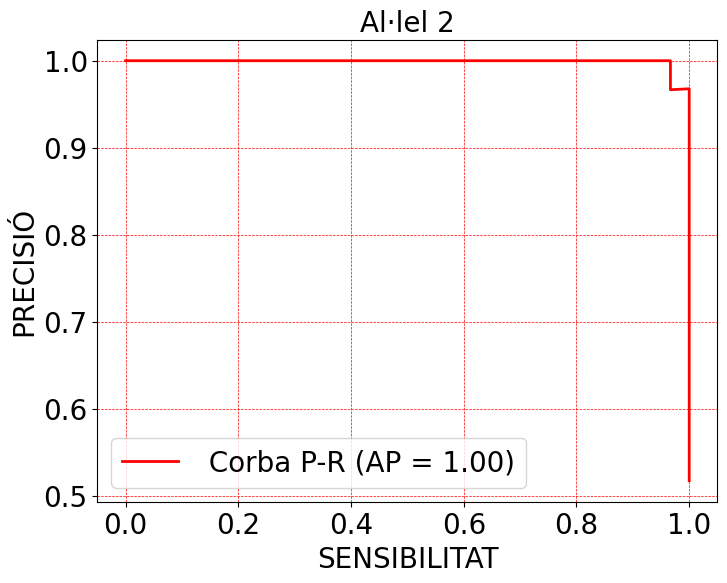

In [21]:
y_proba = clf.predict_proba(X_test_new)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Al·lel 2',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

## ENN

In [22]:
from imblearn.under_sampling import EditedNearestNeighbours

# Crear el objeto ENN
enn = EditedNearestNeighbours(n_neighbors=80)

# Aplicar ENN
X_res, y_res = enn.fit_resample(X, y)

# Comprobar la distribución de clases
print(Counter(y_res))


Counter({0: 12156, 1: 145})


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Entrenar el modelo
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Selección de características
selector = SelectFromModel(estimator=clf, prefit=True)
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar la profundidad
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
    
)
clf.fit(X_train_new, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test_new)


# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# Informe de clasificación
print(classification_report(y_test, y_pred))


C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[[2437    0]
 [   5   19]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2437
           1       1.00      0.79      0.88        24

    accuracy                           1.00      2461
   macro avg       1.00      0.90      0.94      2461
weighted avg       1.00      1.00      1.00      2461



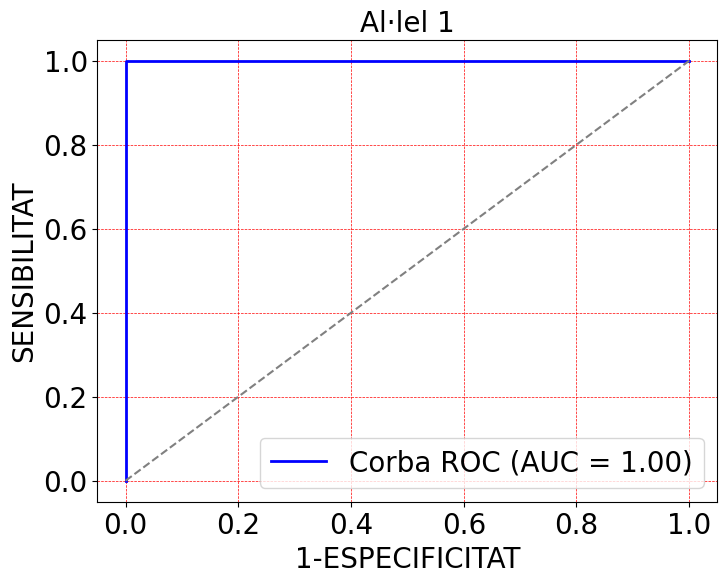

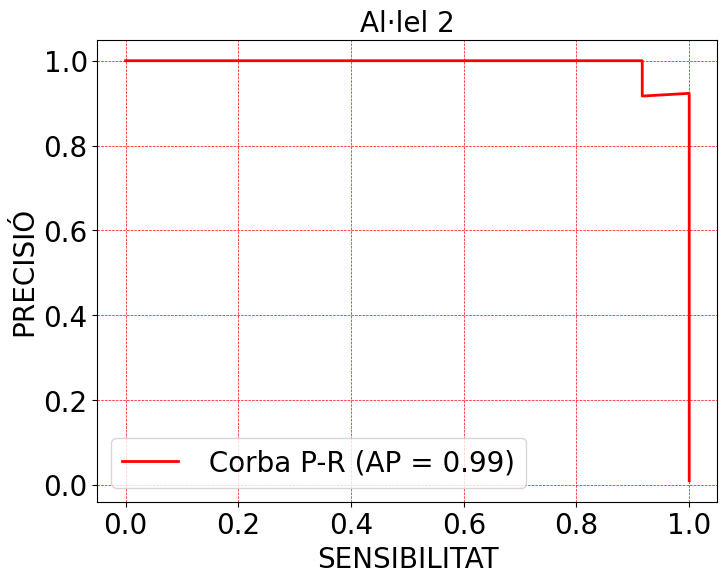

In [27]:
y_proba = clf.predict_proba(X_test_new)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Al·lel 2',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

## NearMiss

In [30]:
from imblearn.under_sampling import NearMiss
from collections import Counter

# Aplicar NearMiss para submuestreo
nearmiss = NearMiss(version=3, n_neighbors=3)
X_res, y_res = nearmiss.fit_resample(X, y)

print("Distribución de clases después de NearMiss:", Counter(y_res))

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Modelo con parámetros ajustados
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,  # Limitar la profundidad
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"  # Penalizar desequilibrio
)
clf.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = clf.predict(X_test)

# Evaluar modelo
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("Informe de Clasificación:\n", classification_report(y_test, y_pred))


Distribución de clases después de NearMiss: Counter({0: 145, 1: 145})
Matriz de Confusión:
 [[25  3]
 [ 2 28]]
Informe de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91        28
           1       0.90      0.93      0.92        30

    accuracy                           0.91        58
   macro avg       0.91      0.91      0.91        58
weighted avg       0.91      0.91      0.91        58



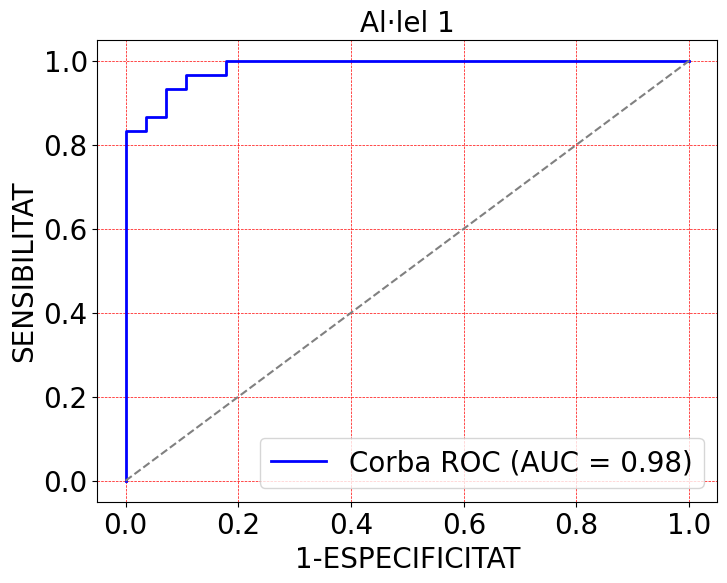

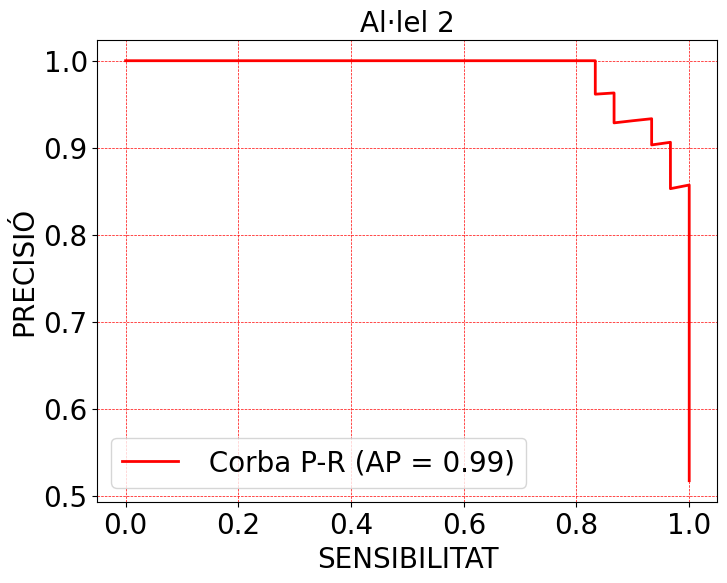

In [31]:
y_proba = clf.predict_proba(X_test)[:, 1]


# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Corba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('1-ESPECIFICITAT',fontsize=20)
plt.ylabel('SENSIBILITAT',fontsize=20)
plt.title('Al·lel 1',fontsize=20)
plt.legend(loc='lower right',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Calcular la curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='red', lw=2, label=f' Corba P-R (AP = {avg_precision:.2f})')
plt.xlabel('SENSIBILITAT',fontsize=20)
plt.ylabel('PRECISIÓ',fontsize=20)
plt.title('Al·lel 2',fontsize=20)
plt.legend(loc='lower left',fontsize=20)
plt.xticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, color='r')
plt.yticks(fontsize=20)
plt.show()

# Regressió

In [6]:
X=NOAnalizadas[NOAnalizadas['CorregirA2']==1].fillna(-9999)
Analizadas_filtradas = Analizadas.loc[X.index]
y=Analizadas_filtradas["Allele 2"]
X = X.drop(columns=["CorregirA2","Allele 2"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(y,bins=10)
plt.title('Histograma Al·lel 2',fontsize=15)
plt.tick_params(axis='both', labelsize=20)
plt.show()

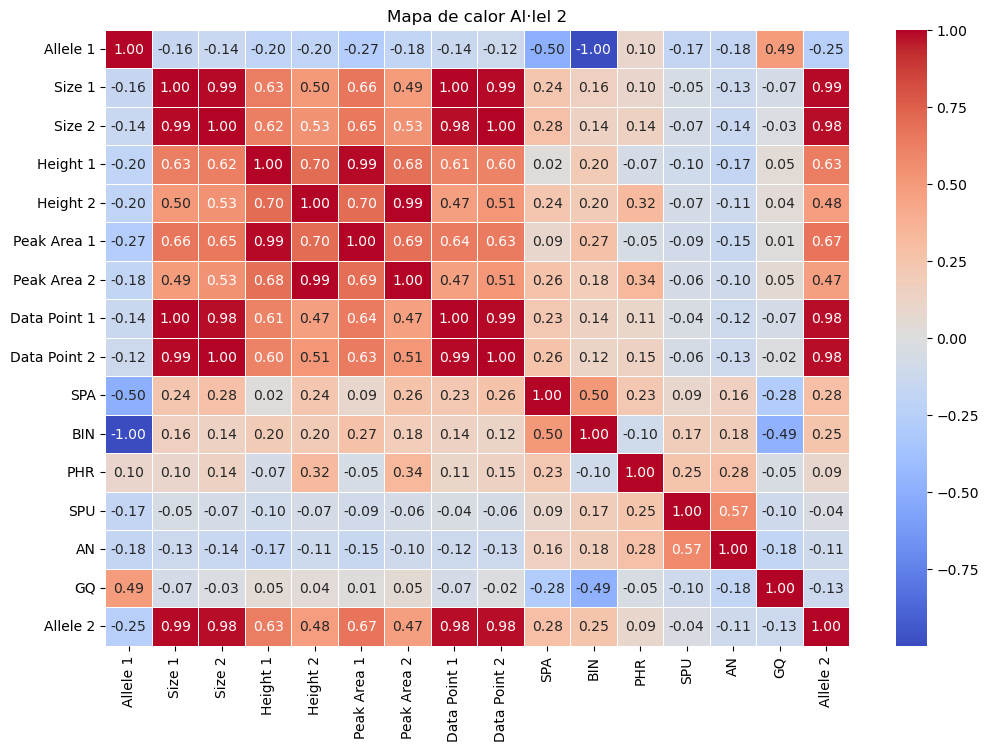

In [48]:
drop=X.drop(["OS","SHP","OBA","SP","LPH","BD","XTLK"], axis=1)
df = pd.concat([drop, y], axis=1)
# Calcular la matriz de correlación
corr_matrix = df.corr()
# Graficar el heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de calor Al·lel 2")
plt.show()


In [10]:
# X=X.drop(["Allele 2","Size 1","Size 2","Data Point 1"], axis=1)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
selected_indices = np.argsort(importances)[-10:]  # Seleccionar las 10 mejores variables

X_train_reducido = X_train.iloc[:, selected_indices]
X_test_reducido = X_test.iloc[:, selected_indices]

print("Características seleccionadas:", X_train.columns[selected_indices].tolist())


Características seleccionadas: ['BIN', 'Peak Area 2', 'Height 2', 'Height 1', 'GQ', 'Allele 1', 'Data Point 2', 'Size 2', 'Data Point 1', 'Size 1']


In [36]:
# Entrenar un nuevo modelo con las características seleccionadas
modelo_reducido = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_reducido.fit(X_train_reducido, y_train)

# Evaluar ambos modelos
y_pred_original = np.round(modelo.predict(X_test))  # Modelo con todas las features
accuracy_original = np.sum(y_pred_original == y_test) / len(y_test)

y_pred_reducido = np.round(modelo_reducido.predict(X_test_reducido))  # Modelo reducido
accuracy_reducido = np.sum(y_pred_reducido == y_test) / len(y_test)

# Comparación de resultados
print(f"Accuracy modelo original: {accuracy_original:.4f}")
print(f"Accuracy modelo reducido: {accuracy_reducido:.4f}")

Accuracy modelo original: 0.5172
Accuracy modelo reducido: 0.1724


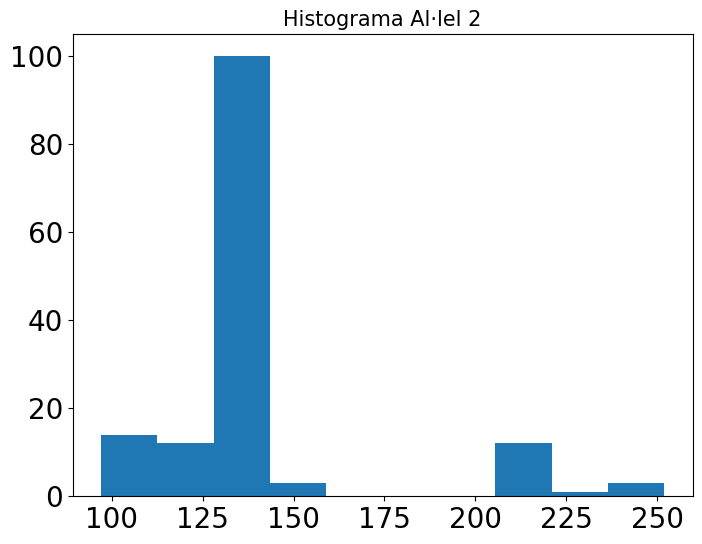

In [46]:
plt.figure(figsize=(8, 6))
plt.hist(y,bins=10)
plt.title('Histograma Al·lel 2',fontsize=15)
plt.tick_params(axis='both', labelsize=20)
plt.show()

## Permutation Importance

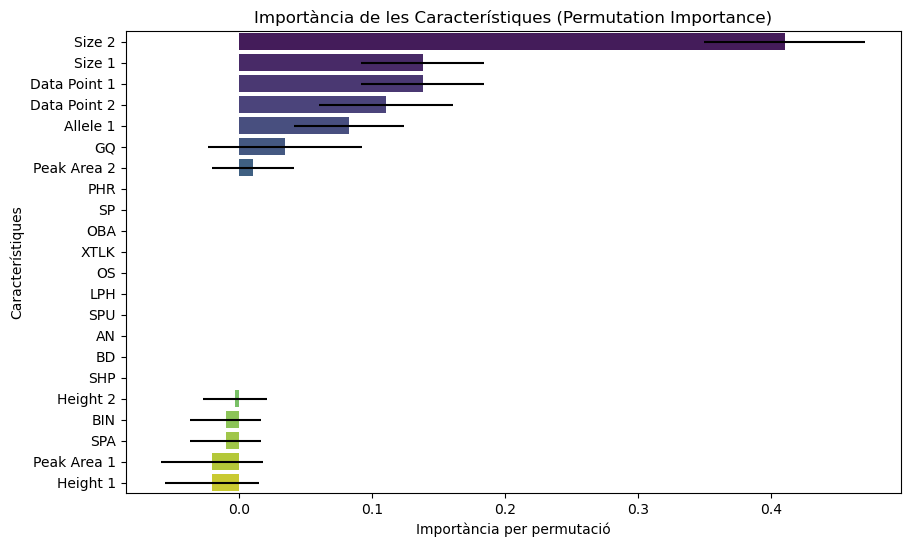

In [15]:
from sklearn.inspection import permutation_importance
# Entrenar un modelo de regresión
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Definir la métrica personalizada
def custom_accuracy(model, X, y):
    y_pred = model.predict(X)
    y_pred_redondeado = np.round(y_pred)  # Redondear predicciones
    aciertos = np.sum(y_pred_redondeado == y)  # Contar aciertos
    return aciertos / len(y)  # Accuracy

# Aplicar Permutation Importance
resultados = permutation_importance(
    modelo, X_test, y_test, scoring=custom_accuracy, n_repeats=10, random_state=42
)

# Seleccionar las mejores características (las 3 más importantes, por ejemplo)
num_features = 1
top_features_idx = np.argsort(resultados.importances_mean)[-num_features:]  # Índices de las mejores características

# Reducir el dataset a solo esas características
X_train_reducido = X_train.iloc[:, top_features_idx]
X_test_reducido = X_test.iloc[:, top_features_idx]

importancias = resultados.importances_mean
errores = resultados.importances_std
features = X_test.columns

# Ordenar por importancia
indices = np.argsort(importancias)[::-1]

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias[indices], y=np.array(features)[indices], xerr=errores[indices], palette="viridis")
plt.xlabel("Importància per permutació")
plt.ylabel("Característiques")
plt.title("Importància de les Característiques (Permutation Importance)")
plt.show()


In [49]:
modelo_reducido = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_reducido.fit(X_train_reducido, y_train)

# Evaluar ambos modelos
y_pred_original = np.round(modelo.predict(X_test))  # Modelo con todas las features
accuracy_original = np.sum(y_pred_original == y_test) / len(y_test)

y_pred_reducido = np.round(modelo_reducido.predict(X_test_reducido))  # Modelo reducido
accuracy_reducido = np.sum(y_pred_reducido == y_test) / len(y_test)

# Comparación de resultados
print(f"Accuracy modelo original: {accuracy_original:.4f}")
print(f"Accuracy modelo reducido: {accuracy_reducido:.4f}")

Accuracy modelo original: 0.5172
Accuracy modelo reducido: 0.6552


## PCA

Varianza explicada por cada componente: [0.44410247 0.17728441 0.1166429  0.10732757 0.06049645 0.04634938]
Varianza total explicada por las 6 primeras componentes: 0.95


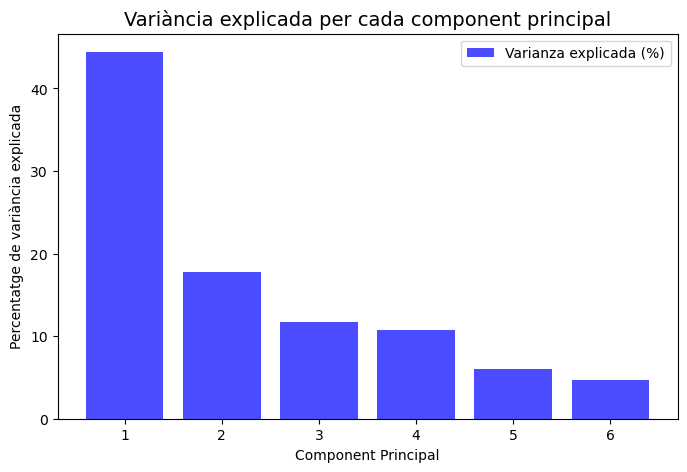

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Estandarizar los datos antes de aplicar PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Aplicar PCA
k = 6  # Número de componentes principales deseadas
pca = PCA(n_components=k)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Entrenar el modelo con las componentes principales
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_pca, y_train)

# Obtener la varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente: {explained_variance}")
print(f"Varianza total explicada por las {k} primeras componentes: {sum(explained_variance):.2f}")

# Visualizar la importancia de cada componente principal
plt.figure(figsize=(8, 5))
plt.bar(range(1, k + 1), explained_variance * 100, alpha=0.7, color='b', label="Variància explicada (%)")
plt.xlabel('Component Principal')
plt.ylabel('Percentatge de variància explicada')
plt.title('Variància explicada per cada component principal', fontsize=14)
plt.legend()
plt.show()

## SelectkBESt

C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\XIMO\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


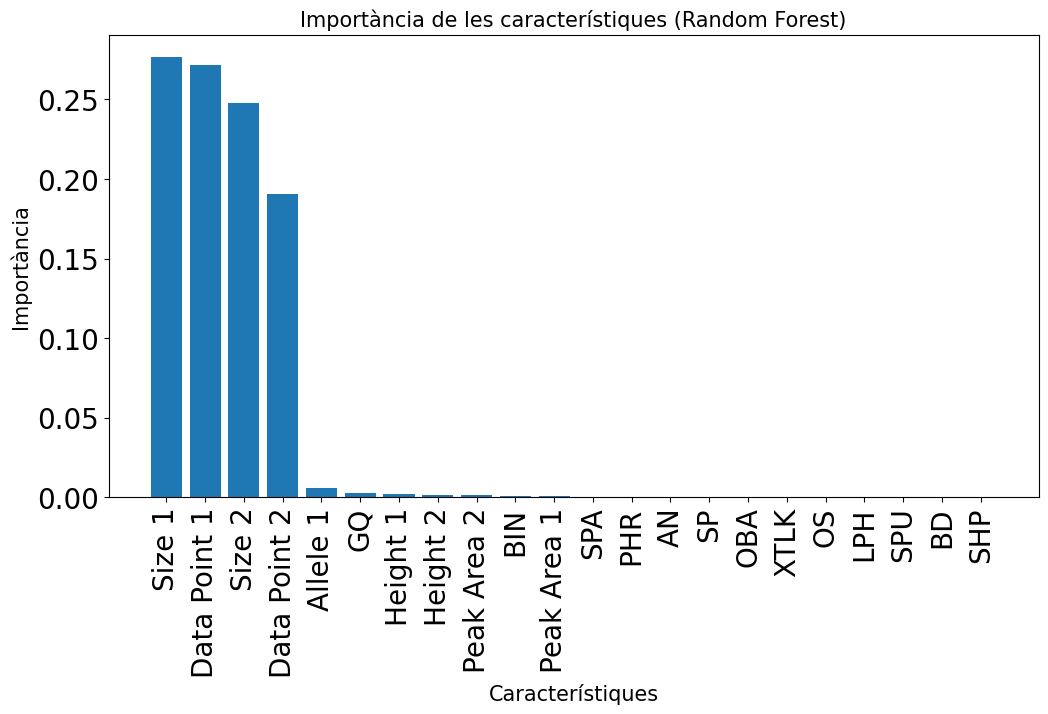

In [17]:
from sklearn.feature_selection import SelectFromModel
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Seleccionar características importantes
selector = SelectFromModel(model,max_features=4, prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Obtener los nombres de las características seleccionadas
mask = selector.get_support()
best_feature_names = X.columns[mask]

# Obtener la importancia de las características
importances = model.feature_importances_
sorted_indices = np.argsort(importances)[::-1]  # Ordenar por importancia descendente

# Visualizar la importancia de las características
plt.figure(figsize=(12, 6))
plt.title("Importància de les característiques (Random Forest)", fontsize=15)
plt.bar(range(len(importances)), importances[sorted_indices], align="center")
plt.xticks(range(len(importances)), X.columns[sorted_indices], rotation=90, fontsize=15)
plt.xlabel("Característiques", fontsize=15)
plt.ylabel("Importància", fontsize=15)
plt.tick_params(axis="both", labelsize=20)
plt.show()


## Models

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: 0.98
Accuracy del regresor: 10.34%
RMSE: 3.6434921070821216


In [27]:
rf = RandomForestRegressor(random_state=42)

# Ajustar el modelo en los datos de entrenamiento
rf.fit(X_train_selected, y_train)
y_pred = rf.predict(X_test_selected)
y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

Accuracy del regresor: 65.52%
RMSE: 2.254085180289335


In [31]:
from sklearn.svm import SVR
model = SVR()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: 0.11
Accuracy del regresor: 6.90%
RMSE: 27.7052636499105


In [44]:
from sklearn.ensemble import ExtraTreesRegressor
model = ExtraTreesRegressor()
model.fit(X_train_reducido, y_train)

y_pred = model.predict(X_test_reducido)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: 1.00
Accuracy del regresor: 79.31%
RMSE: 1.4646171678209488


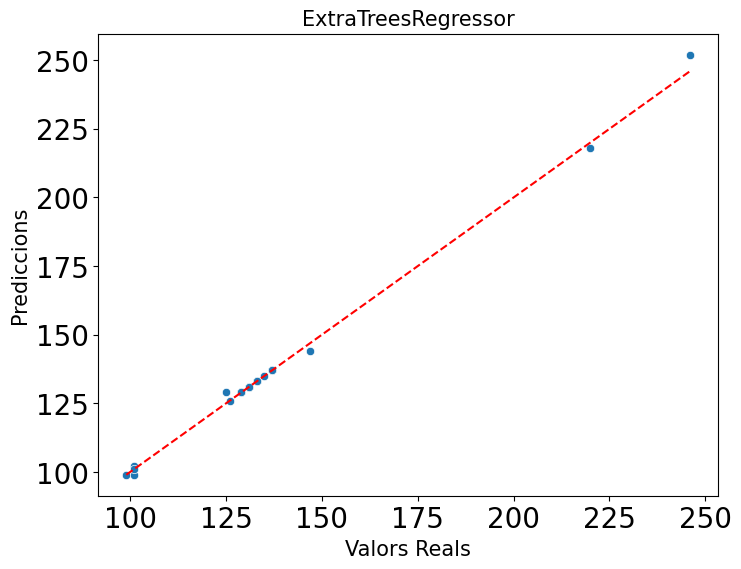

In [45]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_redondeado)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Línea y=x
plt.xlabel('Valors Reals',fontsize=15)
plt.ylabel('Prediccions',fontsize=15)
plt.title('ExtraTreesRegressor',fontsize=15)
plt.tick_params(axis='both', labelsize=20)
plt.show()

In [39]:
from lightgbm import LGBMRegressor
model = LGBMRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 116, number of used features: 12
[LightGBM] [Info] Start training from score 140.801724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [43]:
from xgboost import XGBRegressor
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2:.2f}')

y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: 0.96
Accuracy del regresor: 44.83%
RMSE: 5.6751431397596654


In [56]:
import optuna
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def objective(trial):
    # Definir los hiperparámetros a optimizar con rangos más amplios
    n_estimators = trial.suggest_int('n_estimators', 50, 1000, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 100, step=5)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 50)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_float('max_features', 0.1, 1.0, step=0.1)
    
    model = ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_reducido, y_train)
    y_pred = model.predict(X_test_reducido)
    y_pred_redondeado = np.round(y_pred)
    accuracy = np.sum(y_pred_redondeado == y_test) / len(y_test)

    return accuracy

# Ejecutar la optimización con Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500, n_jobs=-1)  # Aumentado el número de iteraciones

# Mostrar los mejores hiperparámetros encontrados
best_params = study.best_params
print("Mejores hiperparámetros:", best_params)
print("Mejor accuracy obtenido:", study.best_value)
# Entrenar el modelo con los mejores hiperparámetros
best_model = ExtraTreesRegressor(**best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train_reducido, y_train)
y_pred = best_model.predict(X_test_reducido)

# Evaluación final
r2 = r2_score(y_test, y_pred)
y_pred_redondeado = np.round(y_pred)
aciertos = np.sum(y_pred_redondeado == y_test)
accuracy = aciertos / len(y_test)

print(f'R^2 Score: {r2:.2f}')
print(f'Accuracy del regresor: {accuracy*100:.2f}%')
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))



[I 2025-03-06 18:56:33,344] A new study created in memory with name: no-name-dae1e6d1-5f18-4839-ba25-b23508b6a674
[I 2025-03-06 18:56:36,517] Trial 5 finished with value: 0.0 and parameters: {'n_estimators': 50, 'max_depth': 50, 'min_samples_split': 11, 'min_samples_leaf': 15, 'max_features': 0.5}. Best is trial 5 with value: 0.0.
[I 2025-03-06 18:56:38,351] Trial 8 finished with value: 0.0 and parameters: {'n_estimators': 50, 'max_depth': 40, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': 0.30000000000000004}. Best is trial 5 with value: 0.0.
[I 2025-03-06 18:56:38,703] Trial 7 finished with value: 0.10344827586206896 and parameters: {'n_estimators': 200, 'max_depth': 70, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 0.5}. Best is trial 7 with value: 0.10344827586206896.
[I 2025-03-06 18:56:39,897] Trial 4 finished with value: 0.10344827586206896 and parameters: {'n_estimators': 350, 'max_depth': 95, 'min_samples_split': 2, 'min_samples_leaf': 8, 'm

Mejores hiperparámetros: {'n_estimators': 650, 'max_depth': 50, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 0.5}
Mejor accuracy obtenido: 0.7931034482758621
R^2 Score: 0.97
Accuracy del regresor: 51.72%
RMSE: 5.311805694089119


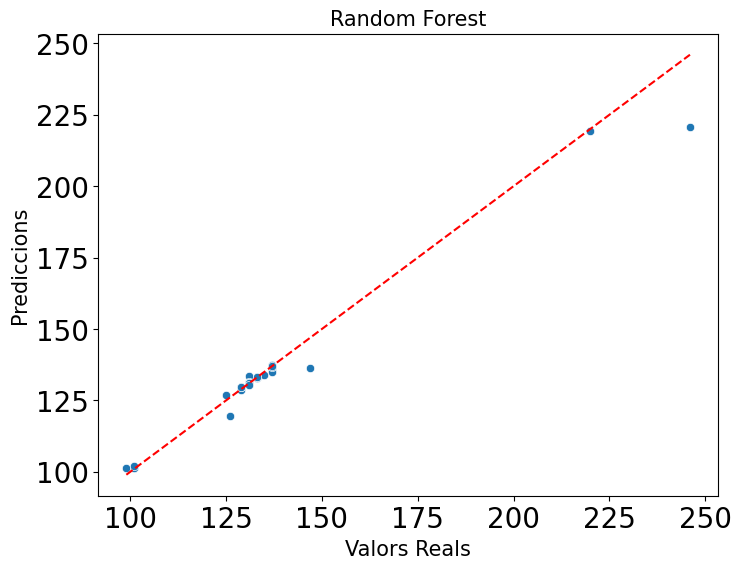

In [57]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Línea y=x
plt.xlabel('Valors Reals',fontsize=15)
plt.ylabel('Prediccions',fontsize=15)
plt.title('Random Forest',fontsize=15)
plt.tick_params(axis='both', labelsize=20)
plt.show()